# Create New Memories


In [45]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel,Field

from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [46]:
store=InMemoryStore()

In [47]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [48]:
class MemoryDescision(BaseModel):
    should_write:bool=Field(description="Wheather to store any Memories")
    memories:List[str]=Field(default_factory=list,description="Atomic user memories to store")

In [49]:
# structured_model=model.with_structured_output(MemoryDescision)
from langchain_core.output_parsers import JsonOutputParser

parser = JsonOutputParser()

structured_model = model | parser

In [50]:
def remember(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id=config['configurable']['user_id']

    namespace=("user",user_id,"details")

    last_msg=state['messages'][-1].content

    descision: MemoryDescision=structured_model.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    if descision["should_write"]:
        for mem in descision["memories"]:
            store.put(namespace,str(uuid.uuid4()),{"data":mem})
    
    return {
        'messages':[{
            "role":"assistant",
            "content":"Noted."
        }]
    }

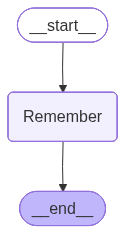

In [51]:
builder = StateGraph(MessagesState)
builder.add_node("Remember", remember)
builder.add_edge(START, "Remember")
builder.add_edge("Remember", END)

graph = builder.compile(store=store)

graph

In [57]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Amrit"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [58]:
res = graph.invoke({"messages": [{"role": "user", "content": "I learn AI from youtube"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [59]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [60]:
items = store.search(("user", "u1", "details"))


for item in items:
    print(item.value['data'])

The user's name is Amrit.
User learns AI through YouTube.
User's favorite programming language is Python.
User's name is Amrit.
The user learns AI from YouTube.
User's favorite programming language is Python.


# Not Create Duplicates

In [ ]:
# to avoid the duplicate memory storing add a memory item which chekc wheather the memory is already present or not

class MemoryItem(BaseModel):
    text:str=Field(description="Atomic user memory as a short sentance")
    is_new:bool=Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [ ]:
class MemoryDescision(BaseModel):
    should_write:bool=Field(description="Wheather to store any Memories")
    # memories is the list of MemoryItem to avoid duplication
    memories:List[MemoryItem]=Field(default_factory=list,description="Atomic user memories to store")